# ECG image analysis: Classification of Cardiac and COVID-19 Patients Using 12-Lead ECG Images

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# import zipfile

# zip_path = '/content/drive/MyDrive/gwbz3fsgp8-1.zip'
# extract_path = ''

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Unzipped successfully!")

In [3]:
dataset_path = '/content/drive/MyDrive/Ecg_Dataset'

In [4]:
import os

In [5]:
abnormal_heatbeat_image=len(os.listdir(os.path.join(dataset_path,"Abnormal_Heartbeat")))
covid_19_image=len(os.listdir(os.path.join(dataset_path,"Covid_19")))
mi_image=len(os.listdir(os.path.join(dataset_path,"MI")))
mi_history_image=len(os.listdir(os.path.join(dataset_path,"MI_History")))
normal_image=len(os.listdir(os.path.join(dataset_path,"Normal")))

In [6]:
print("Normal :",normal_image)
print("covid_19:",covid_19_image)
print("mi:",mi_image)
print("mi_history:",mi_history_image)
print("abnormal_heartbeat :",abnormal_heatbeat_image)

Normal : 859
covid_19: 250
mi: 74
mi_history: 203
abnormal_heartbeat : 546


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
labels=["Abnormal Heartbeat","Covid_19","MI","Past MI History","Normal"]
counts=[abnormal_heatbeat_image,covid_19_image,mi_image,mi_history_image,normal_image]

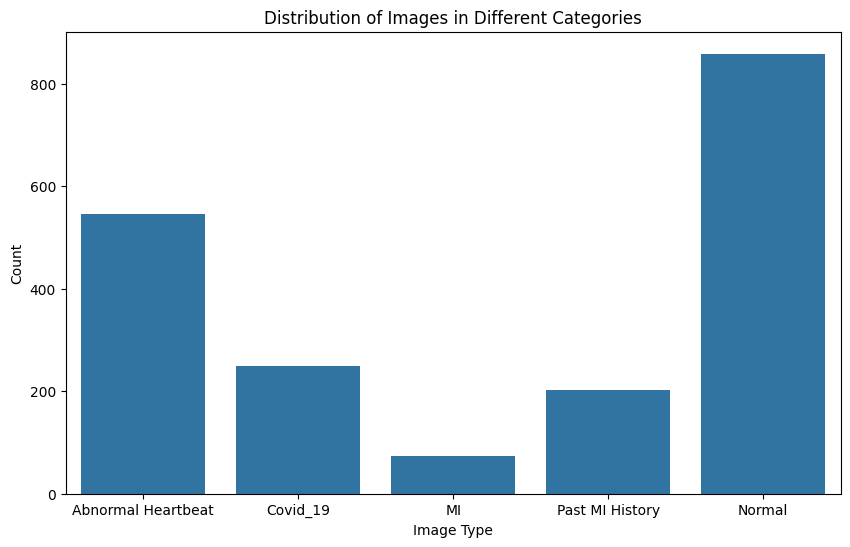

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=counts)
plt.xlabel('Image Type')
plt.ylabel('Count')
plt.title('Distribution of Images in Different Categories')
plt.show()

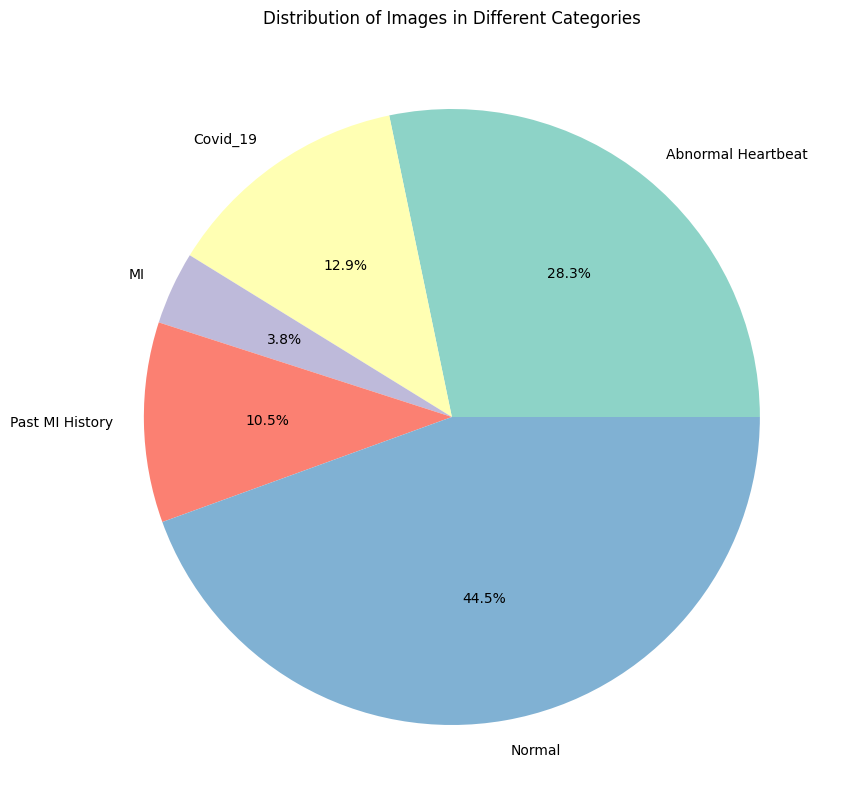

In [10]:
plt.figure(figsize=(10, 10))
sns.set_palette("Set3")
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Images in Different Categories')
plt.show()

In [11]:
import plotly.graph_objects as go

In [12]:
#Interactive Visualization
fig = go.Figure(data=[go.Pie(labels=labels, values=counts, textinfo='percent', insidetextorientation='radial')])
fig.update_layout(
    title='Distribution of Images in Different Categories',
    width=800,
    height=500
)
fig.show()

In [13]:
abnormal_heartbeat_path = os.path.join(dataset_path, "Abnormal_Heartbeat")
covid_19_path = os.path.join(dataset_path, "Covid_19")
mi_path = os.path.join(dataset_path, "MI")
mi_history_path = os.path.join(dataset_path, "MI_History")
normal_path = os.path.join(dataset_path, "Normal")

In [14]:
import cv2

In [15]:
covid_19_files = os.listdir(covid_19_path)
normal_files = os.listdir(normal_path)
mi_files = os.listdir(mi_path)
prev_mi_files = os.listdir(mi_history_path)
abnormal_heartbeat_files = os.listdir(abnormal_heartbeat_path)

In [16]:
def view_image(image_name,image_files,image_file_path):
    fig,axes=plt.subplots(3,3,figsize=(10,10))
    fig.suptitle(image_name,fontsize=16)
    axes=axes.ravel()

    for i,image_file in enumerate(image_files[:9]):
        image_path=os.path.join(image_file_path,image_file)
        image=cv2.imread(image_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

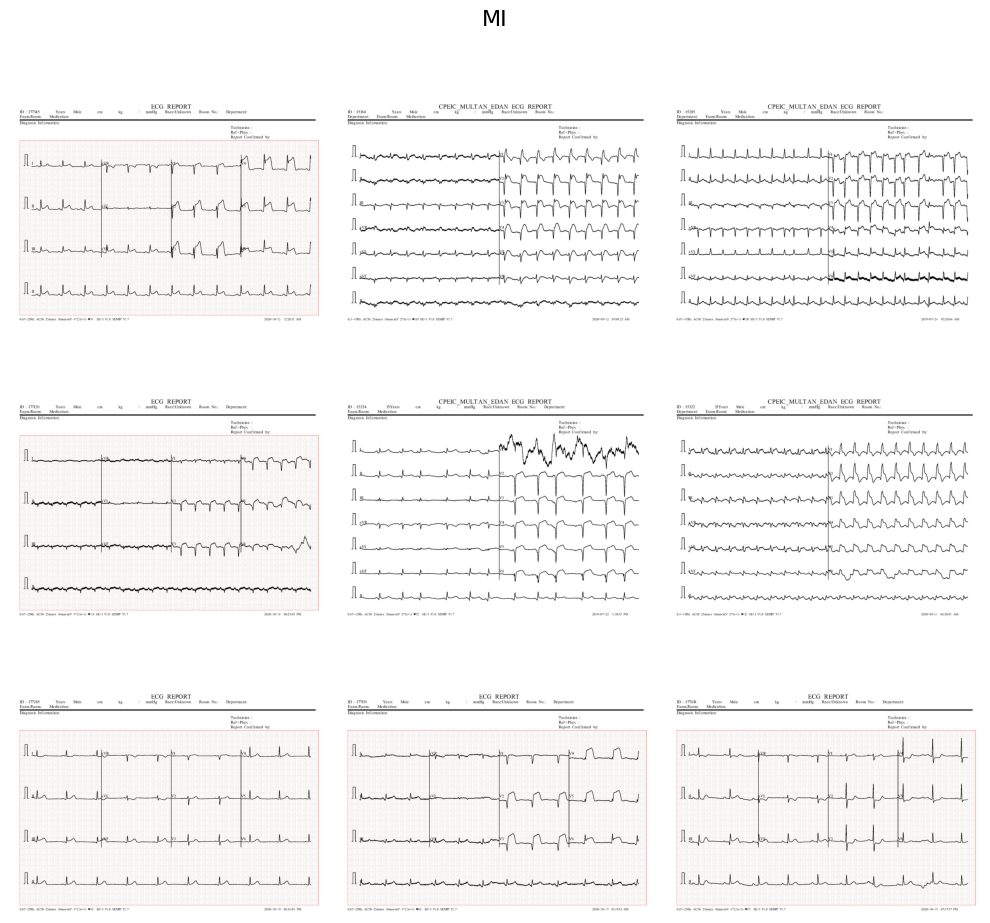

In [17]:
view_image("MI",mi_files,mi_path)

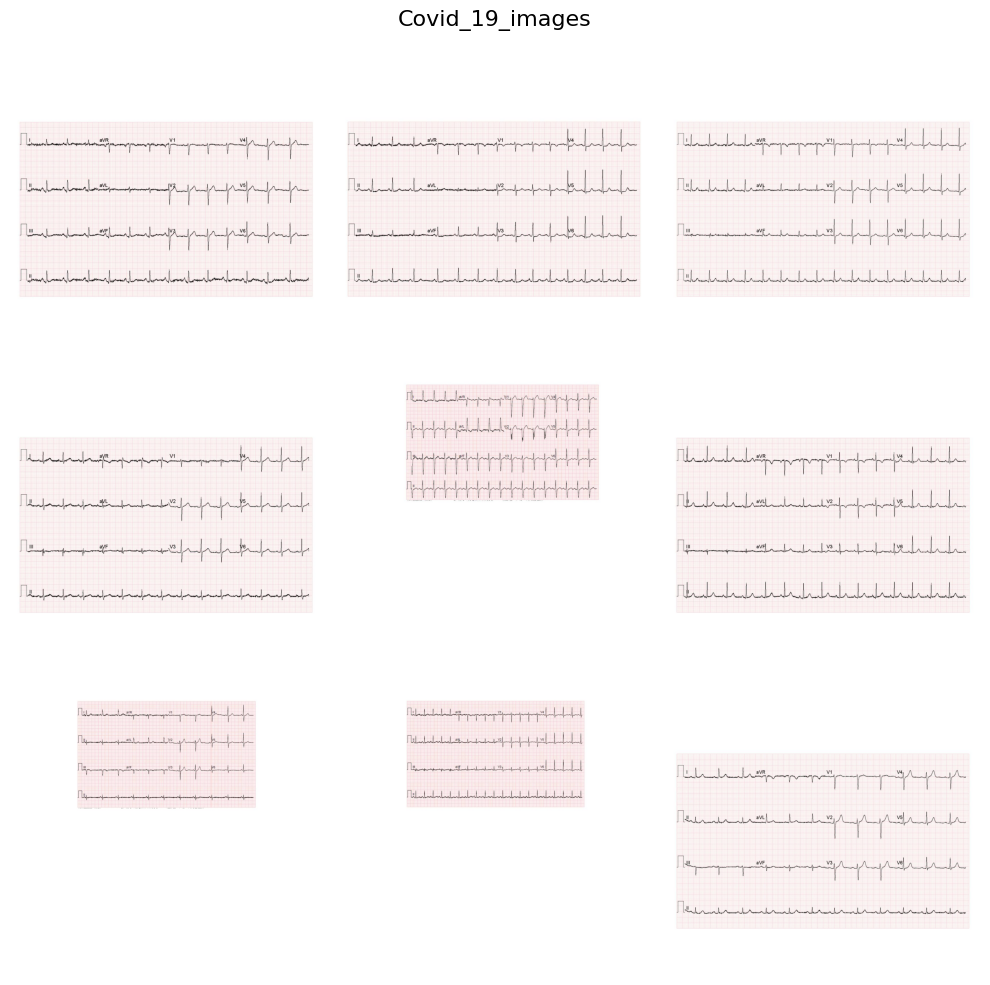

In [18]:
view_image("Covid_19_images",covid_19_files,covid_19_path)

Image Preprocessing

In [19]:
# since it's image data, hence we have to ensure all images have same pixel size
# so resizing the image by 224*224
def load_and_preprocess_image(image_folder):
    image_files = os.listdir(image_folder)
    images = []

    for image_file in image_files :
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            image = cv2.resize(image, (128,128))
            images.append(image)
    return images

In [20]:
abnormal_heartbeat_files = load_and_preprocess_image(abnormal_heartbeat_path)
covid_19_files = load_and_preprocess_image(covid_19_path)
mi_files = load_and_preprocess_image(mi_path)
mi_history_files = load_and_preprocess_image(mi_history_path)
normal_files = load_and_preprocess_image(normal_path)

Convert to NumPy Arrays

In [21]:
import numpy as np

In [22]:
abnormal_heartbeat_files = np.array(abnormal_heartbeat_files).reshape(-1, 128, 128, 3)
covid_19_files = np.array(covid_19_files).reshape(-1, 128, 128, 3)
mi_files = np.array(mi_files).reshape(-1, 128, 128, 3)
mi_history_files = np.array(mi_history_files).reshape(-1, 128, 128, 3)
normal_files = np.array(normal_files).reshape(-1, 128, 128, 3)

Combining Dataset and Label Encoding

In [23]:
all_files = np.concatenate((abnormal_heartbeat_files, covid_19_files, mi_files,mi_history_files,
                           normal_files), axis=0)

all_labels = np.concatenate((
np.zeros(len(abnormal_heartbeat_files)),
np.ones(len(covid_19_files)),
np.ones(len(mi_files)) * 2,
    np.ones(len(mi_history_files)) * 3,
    np.ones(len(normal_files))*4
))

Flattening Images

In [24]:
#converting 4D array into 2-D array using ndarray.reshape(-1,Height,Width,Color Channels)
all_files_flaten=all_files.reshape(-1,all_files.shape[1]*all_files.shape[2]*all_files.shape[3])

In [25]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

Handling Imbalance

In [26]:
ros = RandomOverSampler(random_state=42)
all_files_flat_resampled, all_labels_resampled = ros.fit_resample(all_files_flaten, all_labels)

In [27]:
ros = SMOTE(random_state=42)
all_files_flat_resampled, all_labels_resampled = ros.fit_resample(all_files_flaten, all_labels)

In [28]:
unique_resampled, counts_resampled = np.unique(all_labels_resampled, return_counts=True)
class_counts_resampled = dict(zip(unique_resampled, counts_resampled))

print("New class distribution after resampling:", class_counts_resampled)

New class distribution after resampling: {np.float64(0.0): np.int64(859), np.float64(1.0): np.int64(859), np.float64(2.0): np.int64(859), np.float64(3.0): np.int64(859), np.float64(4.0): np.int64(859)}


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(all_files_flat_resampled, all_labels_resampled, test_size=0.2, stratify=all_labels_resampled,
                                                    random_state=42)

Feature Scaling

In [31]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K-Fold Cross Validation

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC

# adding max_iter + dual=False
svm_model = LinearSVC(random_state=42, max_iter=2000, dual=False)

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    n_jobs=-1
)

print("K-Fold Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

K-Fold Accuracy Scores: [0.84642234 0.85938865 0.87336245]
Mean Accuracy: 0.8597244767573308


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fold_no = 1

for train_idx, val_idx in kfold.split(X_train_scaled, y_train):

    model = LinearSVC(max_iter=2000, dual=False)
    model.fit(X_train_scaled[train_idx], y_train[train_idx])

    y_pred = model.predict(X_train_scaled[val_idx])

    cm = confusion_matrix(y_train[val_idx], y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f'Confusion Matrix - Fold {fold_no}')

    # Save image
    plt.savefig(f'/content/drive/MyDrive/cv_fold_{fold_no}.png')

    plt.close()

    fold_no += 1

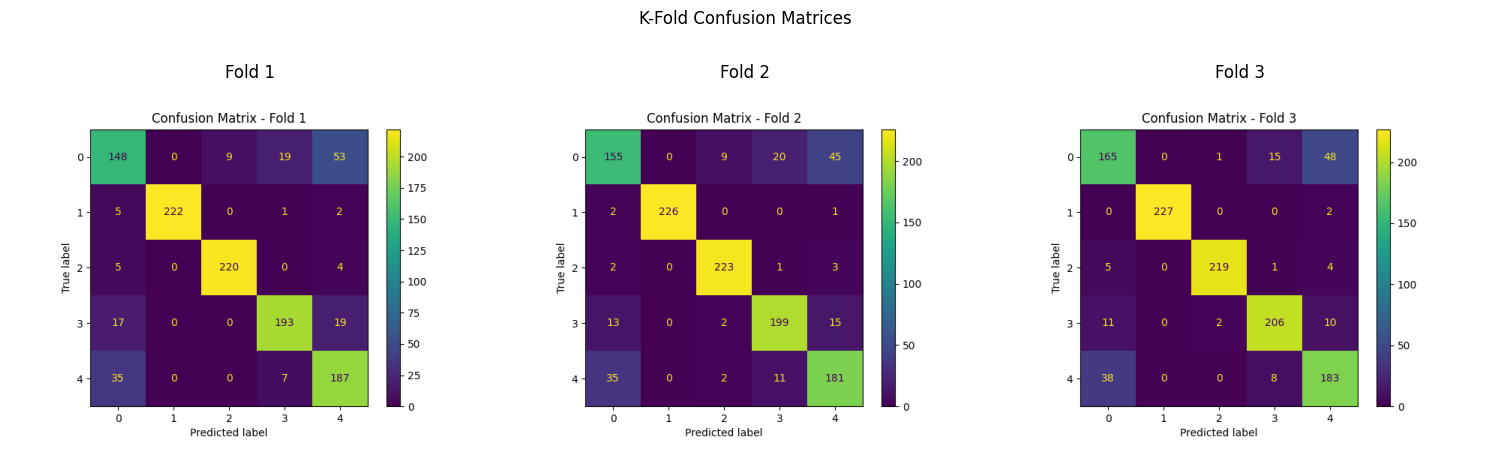

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# paths of saved images
img_paths = [
    '/content/drive/MyDrive/cv_fold_1.png',
    '/content/drive/MyDrive/cv_fold_2.png',
    '/content/drive/MyDrive/cv_fold_3.png'
]

# create subplot (1 row, 3 images)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, path in enumerate(img_paths):
    img = mpimg.imread(path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Fold {i+1}')

plt.suptitle("K-Fold Confusion Matrices")
plt.tight_layout()
plt.show()

In [35]:
X_train

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

In [36]:
X_train_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [37]:
X_test

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

In [38]:
X_test_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

SVM Model

In [39]:
from sklearn.svm import LinearSVC

svm_classifier = LinearSVC(random_state=42)

In [40]:
svm_classifier.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



LinearSVC(random_state=42)

In [41]:
svm_predictions = svm_classifier.predict(X_test_scaled)

Metrics Evaluation

In [42]:
accuracy = accuracy_score(y_test, svm_predictions)
print("Accuracy:", accuracy)

precision = precision_score(y_test, svm_predictions, average=None)
recall = recall_score(y_test, svm_predictions, average=None)
f1 = f1_score(y_test, svm_predictions, average=None)

for class_label, prec, rec, f1_score in zip(["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"], precision, recall, f1):
    print(f"Class {class_label}:")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-score: {f1_score:.4f}\n")

report = classification_report(y_test, svm_predictions)
print("Classification Report:\n", report)

confusion = confusion_matrix(y_test, svm_predictions)
print("Confusion Matrix:\n", confusion)

Accuracy: 0.880093131548312
Class Class 0:
  Precision: 0.7736
  Recall: 0.7151
  F1-score: 0.7432

Class Class 1:
  Precision: 1.0000
  Recall: 0.9942
  F1-score: 0.9971

Class Class 2:
  Precision: 0.9659
  Recall: 0.9884
  F1-score: 0.9770

Class Class 3:
  Precision: 0.8988
  Recall: 0.8779
  F1-score: 0.8882

Class Class 4:
  Precision: 0.7634
  Recall: 0.8256
  F1-score: 0.7933

Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.72      0.74       172
         1.0       1.00      0.99      1.00       171
         2.0       0.97      0.99      0.98       172
         3.0       0.90      0.88      0.89       172
         4.0       0.76      0.83      0.79       172

    accuracy                           0.88       859
   macro avg       0.88      0.88      0.88       859
weighted avg       0.88      0.88      0.88       859

Confusion Matrix:
 [[123   0   6  12  31]
 [  0 170   0   0   1]
 [  1   0 170   0   1]
 [ 10   0  

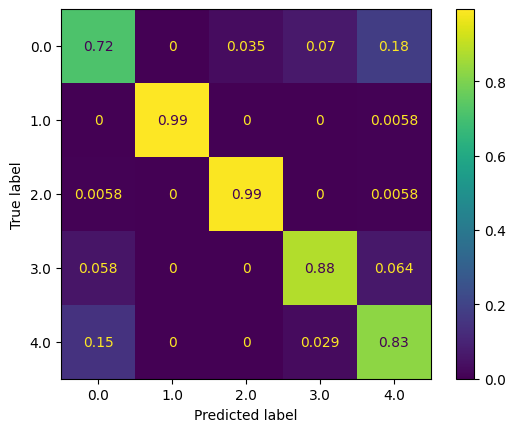

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,svm_predictions, normalize='true')

Random Forest & Decision Tree

In [44]:
rf_classifier = RandomForestClassifier(n_estimators=10,random_state=42)

In [45]:
rf_classifier.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [46]:
rf_predictions = rf_classifier.predict(X_test_scaled)

In [47]:
accuracy = accuracy_score(y_test, rf_predictions)
print("Accuracy:", accuracy)

report = classification_report(y_test, rf_predictions)
print("Classification Report:\n", report)

confusion = confusion_matrix(y_test, rf_predictions)
print("Confusion Matrix:\n", confusion)

Accuracy: 0.8265424912689173
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.65      0.66       172
         1.0       1.00      0.98      0.99       171
         2.0       0.94      0.90      0.92       172
         3.0       0.87      0.76      0.81       172
         4.0       0.68      0.85      0.76       172

    accuracy                           0.83       859
   macro avg       0.84      0.83      0.83       859
weighted avg       0.84      0.83      0.83       859

Confusion Matrix:
 [[111   0   5  14  42]
 [  2 168   0   1   0]
 [ 10   0 154   2   6]
 [ 18   0   4 130  20]
 [ 23   0   0   2 147]]


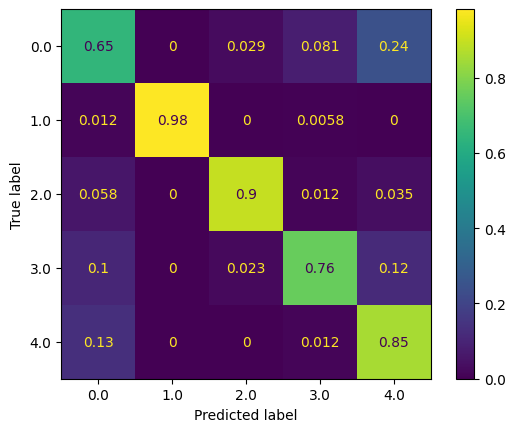

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,rf_predictions, normalize='true')

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dt_classifier = DecisionTreeClassifier(random_state=42)

In [51]:
dt_classifier.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [52]:
dt_predictions = dt_classifier.predict(X_test_scaled)

In [53]:
accuracy = accuracy_score(y_test, dt_predictions)
print("Accuracy:", accuracy)

report = classification_report(y_test, dt_predictions)
print("Classification Report:\n", report)

confusion = confusion_matrix(y_test, dt_predictions)
print("Confusion Matrix:\n", confusion)

Accuracy: 0.7741559953434226
Classification Report:
               precision    recall  f1-score   support

         0.0       0.62      0.59      0.60       172
         1.0       0.98      0.99      0.99       171
         2.0       0.85      0.85      0.85       172
         3.0       0.70      0.74      0.72       172
         4.0       0.71      0.70      0.71       172

    accuracy                           0.77       859
   macro avg       0.77      0.77      0.77       859
weighted avg       0.77      0.77      0.77       859

Confusion Matrix:
 [[101   3  12  32  24]
 [  1 169   0   1   0]
 [ 12   0 146   8   6]
 [ 17   0   7 128  20]
 [ 31   0   6  14 121]]


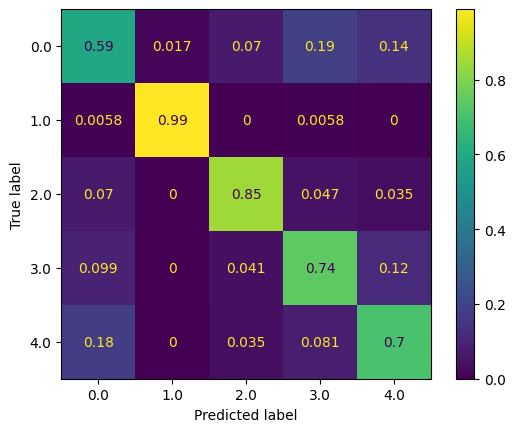

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,dt_predictions, normalize='true')

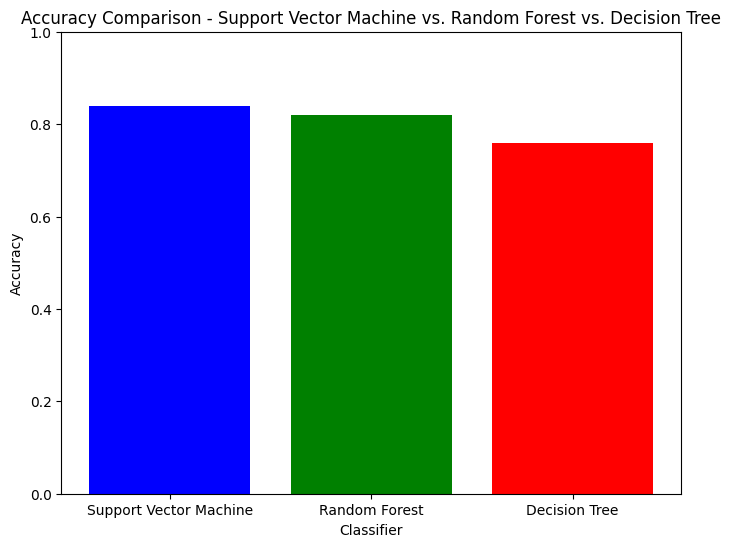

In [55]:
plt.figure(figsize=(8, 6))
classifiers = ['Support Vector Machine', 'Random Forest', 'Decision Tree']
accuracies = [0.84, 0.82, 0.76]
plt.bar(classifiers, accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison - Support Vector Machine vs. Random Forest vs. Decision Tree')
plt.ylim(0, 1)
plt.show()

# **Deep Learning Method**

In [56]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [57]:
pip install tensorflow

Deep Learning Model – ANN (Baseline)

In [58]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [60]:
X_train_scaled.shape

(3436, 49152)

In [61]:
y_train.shape

(3436,)

In [62]:
model = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [63]:
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [64]:
X_train_scaled_new = X_train_scaled.reshape(-1, 128, 128, 3)

In [65]:
history = model.fit(X_train_scaled_new, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.1998 - loss: 5.6020 - val_accuracy: 0.1788 - val_loss: 1.6102
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.2052 - loss: 1.6186 - val_accuracy: 0.1788 - val_loss: 1.6103
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2074 - loss: 1.6655 - val_accuracy: 0.1788 - val_loss: 1.6101
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2052 - loss: 1.6437 - val_accuracy: 0.1788 - val_loss: 1.6104
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2052 - loss: 1.6096 - val_accuracy: 0.1788 - val_loss: 1.6103
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2052 - loss: 1.6096 - val_accuracy: 0.1788 - val_loss: 1.6102
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2052 - loss: 1.6095 - val_accuracy: 0.1788 - val_loss: 1.6101
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2052 - loss: 1.6095 - val_accuracy: 0.1788 - va

 Deep Learning Model – CNN (Improved Model)

In [66]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [67]:
model = Sequential()

In [68]:
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [69]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,573 (24.98 MB)

 Trainable params: 6,549,573 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [71]:
history = model.fit(X_train_scaled_new, y_train, epochs=10, batch_size=16, validation_split=0.2)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.2751 - loss: 1.5629 - val_accuracy: 0.5000 - val_loss: 1.2421
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4985 - loss: 1.0945 - val_accuracy: 0.5683 - val_loss: 0.9259
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5862 - loss: 0.9498 - val_accuracy: 0.6453 - val_loss: 0.8170
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6739 - loss: 0.7819 - val_accuracy: 0.7442 - val_loss: 0.6600
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7369 - loss: 0.6700 - val_accuracy: 0.7718 - val_loss: 0.6371
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7693 - loss: 0.6011 - val_accuracy: 0.7776 - val_loss: 0.5671
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8031 - loss: 0.5186 - val_accuracy: 0.7936 - val_loss: 0.5143
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8326 - loss: 0.4762 - val_acc

In [72]:
X_test_scaled_new = X_test_scaled.reshape(-1, 128, 128, 3)

MC Dropout


In [73]:
import tensorflow as tf
import numpy as np

def mc_dropout_predict(model, X, T=20):
    predictions = []

    for _ in range(T):
        preds = model(X, training=True)  # FORCE dropout ON
        predictions.append(preds.numpy())

    predictions = np.array(predictions)

    mean_pred = np.mean(predictions, axis=0)
    uncertainty = np.std(predictions, axis=0)

    return mean_pred, uncertainty


mean_pred, uncertainty = mc_dropout_predict(model, X_test_scaled_new, T=20)

pred_labels = np.argmax(mean_pred, axis=1)

print("Sample Prediction:", pred_labels[:10])
print("Uncertainty (std):", uncertainty[:5])

Sample Prediction: [3 3 4 2 4 4 1 3 2 4]
Uncertainty (std): [[2.24556755e-02 4.72208631e-04 3.23962241e-01 3.27204615e-01
  1.16144645e-03]
 [2.31312856e-01 1.83246713e-02 1.28164445e-03 2.50413179e-01
  2.27603260e-02]
 [1.43711910e-01 1.03834756e-02 1.14175584e-02 3.73147652e-02
  1.53887495e-01]
 [7.98263180e-04 2.43507002e-05 8.59446172e-03 7.82792363e-03
  2.00375012e-04]
 [9.60316435e-02 1.46376854e-02 5.25929919e-03 2.15416756e-02
  1.13639496e-01]]


In [74]:
predictions = model.predict(X_test_scaled_new)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


In [75]:
predicted_labels = predictions.argmax(axis=1)

Cohen's Kappa


In [76]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, predicted_labels)
print("Cohen's Kappa Score:", kappa)

Cohen's Kappa Score: 0.8210116533768366


In [77]:
accuracy = accuracy_score(y_test, predicted_labels)
conf_matrix = confusion_matrix(y_test, predicted_labels)
class_report = classification_report(y_test, predicted_labels)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.86
Confusion Matrix:
[[119   0   4  24  25]
 [  2 168   0   0   1]
 [  9   0 156   2   5]
 [  9   0   1 153   9]
 [ 24   0   1   7 140]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.69      0.71       172
         1.0       1.00      0.98      0.99       171
         2.0       0.96      0.91      0.93       172
         3.0       0.82      0.89      0.85       172
         4.0       0.78      0.81      0.80       172

    accuracy                           0.86       859
   macro avg       0.86      0.86      0.86       859
weighted avg       0.86      0.86      0.86       859



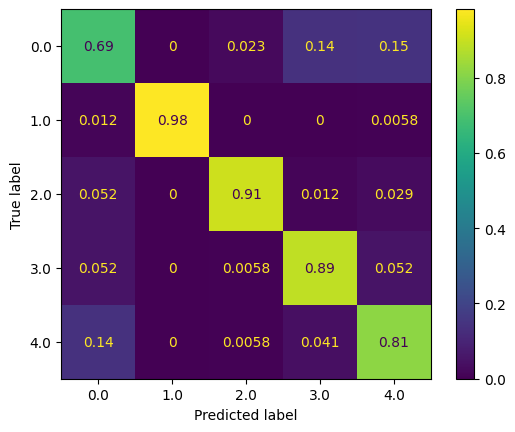

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,predicted_labels, normalize='true')

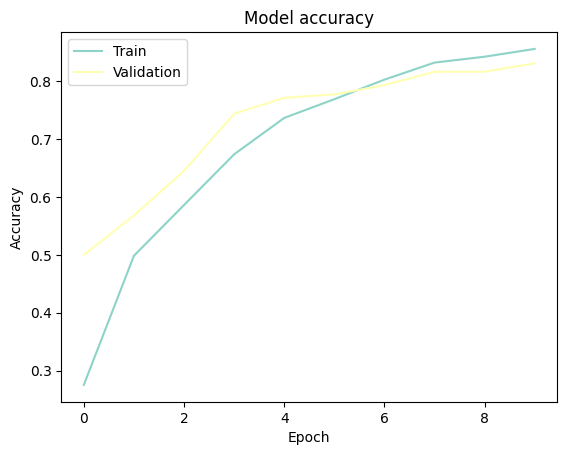

In [79]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

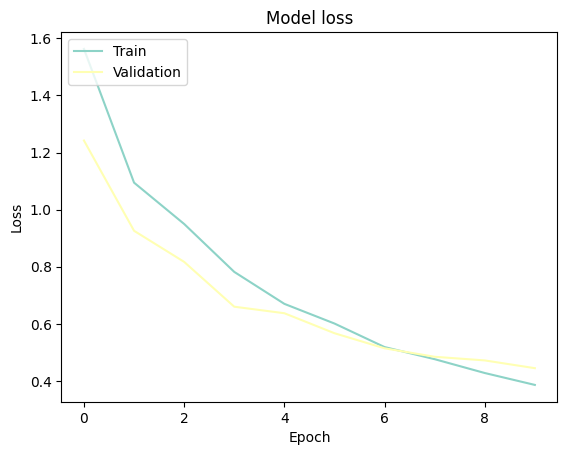

In [80]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [81]:
import os
output_dir = '/content/drive/MyDrive'
os.makedirs(output_dir, exist_ok=True)
model.save(os.path.join(output_dir, 'ecg_model.keras'))

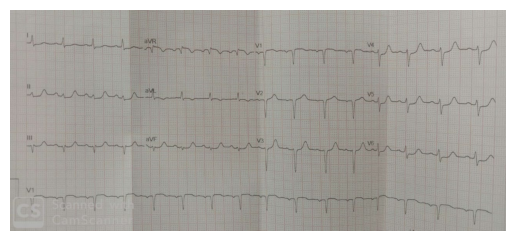

In [82]:
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

# Loading the test image
img_path = r'/content/drive/MyDrive/Ecg_Dataset/ecg.jpeg'
import matplotlib.image as mpimg

img = mpimg.imread(img_path)

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

In [83]:
img = image.load_img(img_path, target_size=(128, 128))
img_array = np.array(img).reshape(-1, 128, 128, 3)
img_array = img_array / 255.0

In [84]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step


In [85]:
predicted_class_index = np.argmax(predictions)
confidence = predictions[0, predicted_class_index]

print("Predicted class index:", predicted_class_index)
print("Confidence:", confidence)

Predicted class index: 3
Confidence: 0.5310699


Grad CAM

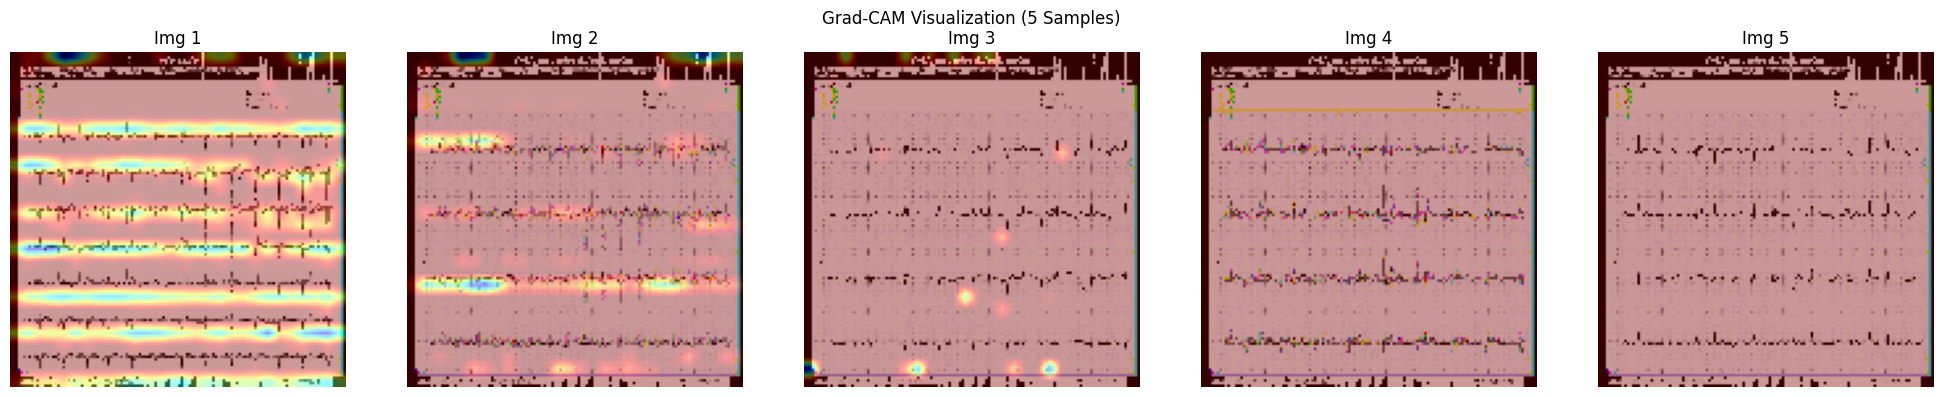

In [86]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def get_gradcam(model, img_array, last_conv_layer_name):
    feature_extractor = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer_name).output
    )

    classifier_input = tf.keras.Input(shape=feature_extractor.output.shape[1:])
    x = classifier_input
    for layer in model.layers[model.layers.index(model.get_layer(last_conv_layer_name)) + 1:]:
        x = layer(x)
    classifier_model = tf.keras.models.Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        img_array_tf = tf.cast(img_array, tf.float32)

        features = feature_extractor(img_array_tf, training=False)
        tape.watch(features)
        predictions = classifier_model(features, training=False)

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, features)

    if grads is None:
        raise ValueError("Gradient is None.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs_single_image = features[0]
    heatmap = conv_outputs_single_image @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_heatmap = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_heatmap + 1e-8)

    return heatmap.numpy()

output_dir = '/content/drive/MyDrive/gradcam_outputs'
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):

    img_array = X_test_scaled_new[i:i+1]

    heatmap = get_gradcam(model, img_array, last_conv_layer_name='conv2d_2')

    img_display = (img_array[0] * 255).astype('uint8')

    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img_display, 0.6, heatmap_colored, 0.4, 0)

    # Save individual image
    cv2.imwrite(f'{output_dir}/gradcam_{i+1}.png', superimposed_img)

    # Add to combined figure
    axes[i].imshow(superimposed_img)
    axes[i].axis('off')
    axes[i].set_title(f'Img {i+1}')

# Combined output
plt.suptitle("Grad-CAM Visualization (5 Samples)")
plt.tight_layout()

# Save combined image
plt.savefig(f'{output_dir}/gradcam_combined.png')

plt.show()